In [18]:
import os

folders = [
    "data/raw",
    "data/processed",
    "notebooks",
    "models",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [19]:
import os

base_path = "data/raw/chest_xray"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}:")

    for category in os.listdir(os.path.join(base_path, split)):
        path = os.path.join(base_path, split, category)
        print(category, "->", len(os.listdir(path)), "images")


TRAIN:
NORMAL -> 1342 images
PNEUMONIA -> 3876 images

VAL:
NORMAL -> 9 images
PNEUMONIA -> 9 images

TEST:
NORMAL -> 234 images
PNEUMONIA -> 390 images


In [20]:
import cv2
import numpy as np
from tqdm import tqdm
import random

In [21]:
IMG_SIZE = 224
CATEGORIES = ["NORMAL", "PNEUMONIA"]
DATA_DIR = "data/raw/chest_xray/train"

In [22]:
data = []

for category in CATEGORIES:
    path = os.path.join(DATA_DIR, category)
    label = CATEGORIES.index(category)

    for img in tqdm(os.listdir(path)):
        try:
            img_path = os.path.join(path, img)

            # Read image
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            # Resize
            resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

            data.append([resized, label])
        except:
            pass

print("Total images loaded:", len(data))

100%|█████████████████████████████████████████████████████████████████████████████| 3876/3876 [00:22<00:00, 172.85it/s]

Total images loaded: 5216


In [23]:
random.shuffle(data)

In [24]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5216, 224, 224)
Shape of y: (5216,)


In [25]:
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [26]:
X = X / 255.0

In [27]:
def load_data(folder):
    data = []

    for category in CATEGORIES:
        path = os.path.join(folder, category)
        label = CATEGORIES.index(category)

        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized, label])
            except:
                pass

    random.shuffle(data)

    X, y = [], []
    for features, label in data:
        X.append(features)
        y.append(label)

    X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    y = np.array(y)

    return X, y

In [28]:
X_train, y_train = load_data("data/raw/chest_xray/train")
X_val, y_val = load_data("data/raw/chest_xray/val")
X_test, y_test = load_data("data/raw/chest_xray/test")

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (5216, 224, 224, 1)
Val: (16, 224, 224, 1)
Test: (624, 224, 224, 1)


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [30]:
import pickle

pickle.dump(X_train, open("data/processed/X_train.pkl", "wb"))
pickle.dump(y_train, open("data/processed/y_train.pkl", "wb"))

pickle.dump(X_val, open("data/processed/X_val.pkl", "wb"))
pickle.dump(y_val, open("data/processed/y_val.pkl", "wb"))

pickle.dump(X_test, open("data/processed/X_test.pkl", "wb"))
pickle.dump(y_test, open("data/processed/y_test.pkl", "wb"))

print("Data saved successfully!")

Data saved successfully!


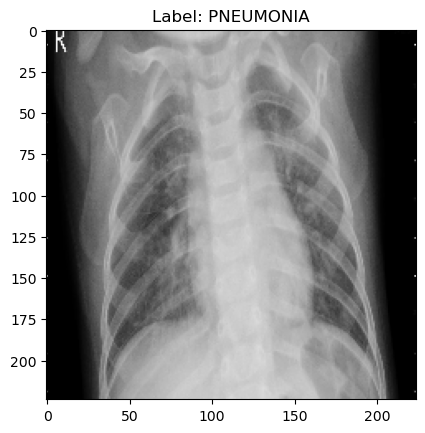

In [32]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].reshape(224,224), cmap="gray")
plt.title("Label: " + CATEGORIES[y_train[0]])
plt.show()

In [33]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

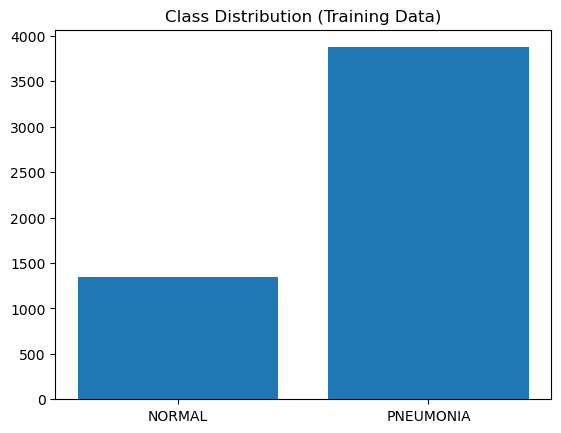

{'NORMAL': np.int64(1341), 'PNEUMONIA': np.int64(3875)}


In [34]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(y_train, return_counts=True)

plt.bar(["NORMAL", "PNEUMONIA"], counts)
plt.title("Class Distribution (Training Data)")
plt.show()

print(dict(zip(["NORMAL", "PNEUMONIA"], counts)))

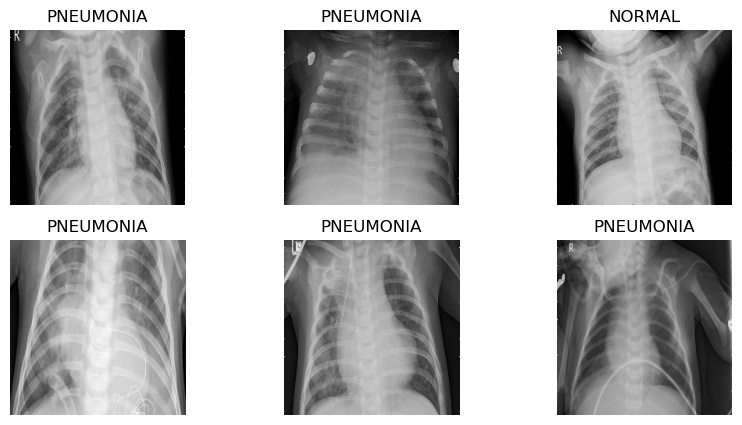

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[i].reshape(224,224), cmap='gray')
    plt.title(CATEGORIES[y_train[i]])
    plt.axis('off')

plt.show()

In [36]:
import os
import cv2

sample_img = cv2.imread("data/raw/chest_xray/train/NORMAL/IM-0115-0001.jpeg", 0)
print("Original shape:", sample_img.shape)

Original shape: (1858, 2090)


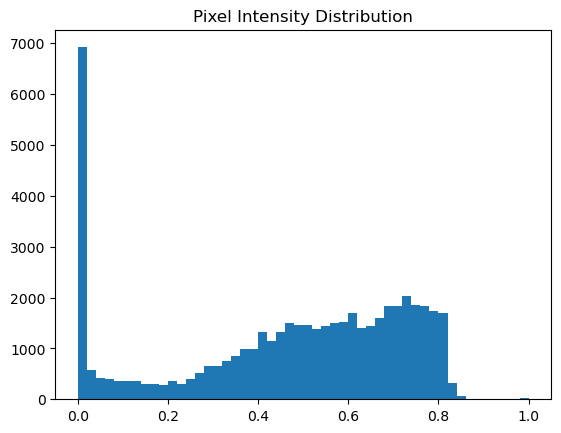

In [37]:
plt.hist(X_train[0].ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

print("\n===== ML MODEL ACCURACY =====")

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))


In [6]:
import os
import cv2

img = cv2.imread("data/raw/chest_xray/train/NORMAL/IM-0115-0001.jpeg", 0)
print("Image shape:", img.shape)

Image shape: (1858, 2090)
